In [2]:
%matplotlib inline
from matplotlib.gridspec import GridSpec
from matplotlib.gridspec import GridSpecFromSubplotSpec
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as colors
from matplotlib.colors import ListedColormap
from matplotlib_venn import venn2
from matplotlib import rcParams
import seaborn as sns
mpl.style.use('seaborn-white')
import multiprocess as mp
import numpy as np
import pandas as pd
import bioframe
import cooltools
import cooltools.expected
import cooltools.saddle
import cooler
import cython
import os
import h5py
import re
import pybedtools
from pybedtools import bedtool
import itertools
import scipy.ndimage.filters
from cycler import cycler

In [3]:
# define conditions, directories and paths
dataDir = f'//nl/umw_job_dekker/users/ou97w/HiC_analyses/Time_course_MN_HiC/scaling_plots/'
outDataDir = f'//nl/umw_job_dekker/users/ou97w/HiC_analyses/Time_course_MN_HiC/scaling_plots/'
figureDir = f'{outDataDir}figures/'

conditions = [
    'N6IPSC2_EP_W0','N6IPSC2_MN_W0','N6IPSC2_MN_W3','N6IPSC2_MN_W6',
    'N9IPSC2_EP_W0','N9IPSC2_MN_W0','N9IPSC2_MN_W3','N9IPSC2_MN_W6'
]

long_name = {
    'N6IPSC2_EP_W0': 'OU-HiC-N6IPSC2-EP-W0',
    'N6IPSC2_MN_W0': 'OU-HiC-N6IPSC2-MN-W0',
    'N6IPSC2_MN_W3': 'OU-HiC-N6IPSC2-MN-W3',
    'N6IPSC2_MN_W6': 'OU-HiC-N6IPSC2-MN-W6',
    'N9IPSC2_EP_W0': 'OU-HiC-N9IPSC2-EP-W0',
    'N9IPSC2_MN_W0': 'OU-HiC-N9IPSC2-MN-W0',
    'N9IPSC2_MN_W3': 'OU-HiC-N9IPSC2-MN-W3',
    'N9IPSC2_MN_W6': 'OU-HiC-N9IPSC2-MN-W6'
}

In [4]:
#set color for each sample (same across replicates)
timeColors = {
    'N6IPSC2_EP_W0' : '#800002',
    'N6IPSC2_MN_W0' : '#6ED2FF',
    'N6IPSC2_MN_W3' : '#0080FF',
    'N6IPSC2_MN_W6' : '#0000FF',
    'N9IPSC2_EP_W0' : '#800002',
    'N9IPSC2_MN_W0' : '#6ED2FF',
    'N9IPSC2_MN_W3' : '#0080FF',
    'N9IPSC2_MN_W6' : '#0000FF',
}

groupColors = {
    'N6IPSC2_EP_W0' : '#aaaaaa',
    'N6IPSC2_MN_W0' : '#aaaaaa',
    'N6IPSC2_MN_W3' : '#aaaaaa',
    'N6IPSC2_MN_W6' : '#aaaaaa',
    'N9IPSC2_EP_W0' : '#aaaaaa',
    'N9IPSC2_MN_W0' : '#aaaaaa',
    'N9IPSC2_MN_W3' : '#333333',
    'N9IPSC2_MN_W6' : '#333333',
}

groupLine = {
    'N6IPSC2_EP_W0' : '-',
    'N6IPSC2_MN_W0' : '-',
    'N6IPSC2_MN_W3' : '-',
    'N6IPSC2_MN_W6' : '-',
    'N9IPSC2_EP_W0' : '-',
    'N9IPSC2_MN_W0' : '-',
    'N9IPSC2_MN_W3' : '-',
    'N9IPSC2_MN_W6' : '-',
}

In [5]:
N6_EP_W0 = [k for k in conditions if 'N6IPSC2_EP_W0' in k]
N6_MN_W0 = [k for k in conditions if 'N6IPSC2_MN_W0' in k]
N6_MN_W3 = [k for k in conditions if 'N6IPSC2_MN_W3' in k]
N6_MN_W6 = [k for k in conditions if 'N6IPSC2_MN_W6' in k]
N9_EP_W0 = [k for k in conditions if 'N9IPSC2_EP_W0' in k]
N9_MN_W0 = [k for k in conditions if 'N9IPSC2_MN_W0' in k]
N9_MN_W3 = [k for k in conditions if 'N9IPSC2_MN_W3' in k]
N9_MN_W6 = [k for k in conditions if 'N9IPSC2_MN_W6' in k]

In [6]:
scale_all = {}
for cond in conditions:
        scale_all[cond] = np.load(f'{dataDir}{long_name[cond]}_50bins.scalingdata.npz')

scale_N6_EP_W0 = {}
for cond in N6_EP_W0:
        scale_N6_EP_W0[cond] = np.load(f'{dataDir}{long_name[cond]}_50bins.scalingdata.npz')

scale_N6_MN_W0 = {}
for cond in N6_MN_W0:
        scale_N6_MN_W0[cond] = np.load(f'{dataDir}{long_name[cond]}_50bins.scalingdata.npz')

scale_N6_MN_W3 = {}
for cond in N6_MN_W3:
        scale_N6_MN_W3[cond] = np.load(f'{dataDir}{long_name[cond]}_50bins.scalingdata.npz')

scale_N6_MN_W6 = {}
for cond in N6_MN_W6:
        scale_N6_MN_W6[cond] = np.load(f'{dataDir}{long_name[cond]}_50bins.scalingdata.npz')

scale_N9_EP_W0 = {}
for cond in N9_EP_W0:
        scale_N9_EP_W0[cond] = np.load(f'{dataDir}{long_name[cond]}_50bins.scalingdata.npz')

scale_N9_MN_W0 = {}
for cond in N9_MN_W0:
        scale_N9_MN_W0[cond] = np.load(f'{dataDir}{long_name[cond]}_50bins.scalingdata.npz')

scale_N9_MN_W3 = {}
for cond in N9_MN_W3:
        scale_N9_MN_W3[cond] = np.load(f'{dataDir}{long_name[cond]}_50bins.scalingdata.npz')

scale_N9_MN_W6 = {}
for cond in N9_MN_W6:
        scale_N9_MN_W6[cond] = np.load(f'{dataDir}{long_name[cond]}_50bins.scalingdata.npz')

<Figure size 432x288 with 0 Axes>

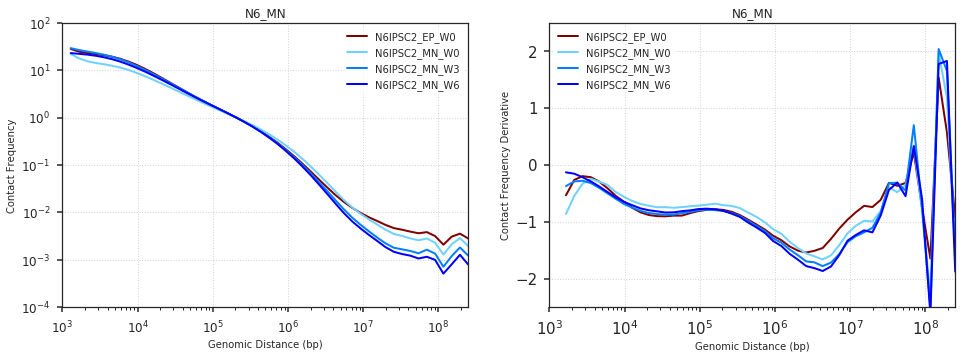

In [9]:
plt.clf()

gs = plt.GridSpec(nrows=12, ncols=2)
plt.figure(figsize=(16, 80))
plt.subplots_adjust(wspace=0.2, hspace=0.3)
def ScalePlotz():
    plt.xlim(1e3, 2.5e8)
    plt.ylim(1e-4, 1e2)
    #plt.grid(axis='x', which='minor', color='lightgray', linestyle=':', linewidth=0.5)
    plt.grid(axis='both', which='major', color='lightgray', linestyle=':', linewidth=1)
    plt.rc('font', weight='normal')
    plt.rc('xtick.major', size=5, pad=7, width=1.5)
    plt.rc('ytick.major', size=5, pad=7, width=1.5)
    #plt.rc('xtick.minor', size=3, pad=7, width=1)
    #plt.rc('ytick.minor', size=0)
    plt.rc('xtick', labelsize=15)
    plt.rc('ytick', labelsize=15)
    plt.legend(loc=0, shadow=False, fontsize='medium', frameon=True, facecolor='#FFFFFF', edgecolor='#FFFFFF', framealpha=0.7)
    plt.ylabel("Contact Frequency")
    plt.xlabel("Genomic Distance (bp)")
    
def DerivPlotz():
    plt.xlim(1e3, 2.5e8)
    plt.ylim(-2.5, 2.5)
    #plt.grid(axis='x', which='minor', color='lightgray', linestyle=':', linewidth=0.5)
    plt.grid(axis='both', which='major', color='lightgray', linestyle=':', linewidth=1)
    plt.rc('font', weight='normal')
    plt.rc('xtick.major', size=5, pad=7, width=1.5)
    plt.rc('ytick.major', size=5, pad=7, width=1.5)
    plt.rc('xtick.minor', size=3, pad=7, width=1)
    #plt.rc('ytick.minor', size=0)
    plt.rc('xtick', labelsize=15)
    plt.rc('ytick', labelsize=15)
    plt.legend(loc=0, shadow=False, fontsize='medium', frameon=True, facecolor='#FFFFFF', edgecolor='#FFFFFF', framealpha=0.7)
    ax = plt.gca()
    ax.set_xscale('log')
    plt.ylabel("Contact Frequency Derivative")
    plt.xlabel("Genomic Distance (bp)")

def DerivPlotzZoom():
    plt.xlim(5e3, 2e6)
    plt.ylim(-2.5, 2.5)
    plt.grid(axis='x', which='minor', color='lightgray', linestyle=':', linewidth=0.5)
    plt.grid(axis='both', which='major', color='lightgray', linestyle='-', linewidth=1)
    plt.rc('font', weight='normal')
    plt.rc('xtick.major', size=5, pad=7, width=1.5)
    plt.rc('ytick.major', size=5, pad=7, width=1.5)
    #plt.rc('xtick.minor', size=3, pad=7, width=1)
    #plt.rc('ytick.minor', size=0)
    plt.rc('xtick', labelsize=12)
    plt.rc('ytick', labelsize=12)
    plt.legend(loc=0, shadow=False, fontsize='small', frameon=True, facecolor='#FFFFFF', edgecolor='#FFFFFF', framealpha=0.7)
    ax = plt.gca()
    ax.set_xscale('log')
    plt.ylabel("Contact Frequency Derivative")
    plt.xlabel("Genomic Distance (bp)")

plt.subplot(gs[0])
for cond in conditions[0:4]:
    plt.loglog(scale_all[cond]["Distbins"][1:], scale_all[cond]["Avarage"]/scale_all[cond]["Avarage"][20], lw=2, ls=groupLine[cond], label = cond, color=timeColors[cond])
    plt.title('N6_MN')
    ScalePlotz()

plt.subplot(gs[1])
for cond in conditions[0:4]:
    delta_x = np.diff(np.log(scipy.ndimage.filters.gaussian_filter1d(scale_all[cond]["Distbins"], sigma=0.1)))
    delta_y = np.diff(np.log(scipy.ndimage.filters.gaussian_filter1d((scale_all[cond]["Avarage"]),sigma=0.1)))
    plt.plot(scale_all[cond]["Distbins"][2:], delta_y/delta_x[:1], lw=2, ls=groupLine[cond], label = cond, color=timeColors[cond])
    plt.title('N6_MN')
    DerivPlotz()

from matplotlib.backends.backend_pdf import PdfPages
pp = PdfPages(f'{figureDir}N6_MN_timecourse_deneme.pdf')
plt.savefig(pp, format='pdf')
pp.close()

In [10]:
# define conditions, directories and paths
dataDir = f'//nl/umw_job_dekker/users/ou97w/HiC_analyses/ALS/scaling_plots/'
outDataDir = f'//nl/umw_job_dekker/users/ou97w/HiC_analyses/ALS/scaling_plots/'
figureDir = f'{outDataDir}figures/'

conditions = [
    'N6_pfib_D4','N6_pfib_D16','N6_IPSC1','N6_IPSC2',
    'N6_MN_C1','N6_MN_C2','N6_EP_C2_W0','N6_MN_C2_W0','N6_MN_C2_W3'
]

long_name = {
    'N6_pfib_D4': 'N6-pfib-D4',
    'N6_pfib_D16': 'N6-pfib-D16',
    'N6_IPSC1': 'N6IPSC1-R1',
    'N6_IPSC2': 'N6IPSC2-R1',
    'N6_MN_C1': 'N6IPSC1MND45-R2',
    'N6_MN_C2': 'N6IPSC2MND45-R2',
    'N6_EP_C2_W0': 'OU-HiC-N6IPSC2-EP-W0',
    'N6_MN_C2_W0': 'OU-HiC-N6IPSC2-MN-W0',
    'N6_MN_C2_W3': 'OU-HiC-N6IPSC2-MN-W3'
}

In [11]:
#set color for each sample (same across replicates)
timeColors = {
    'N6_pfib_D4' : '#FB0207',
    'N6_pfib_D16' : '#FB0207',
    'N6_IPSC1' : '#FC6666',
    'N6_IPSC2' : '#FC6666',
    'N6_MN_C1' : '#0000FF',
    'N6_MN_C2' : '#0000FF',
    'N6_EP_C2_W0' : '#800002',
    'N6_MN_C2_W0' : '#6ED2FF',
    'N6_MN_C2_W3' : '#0080FF',
}

groupColors = {
    'N6_pfib_D4' : '#aaaaaa',
    'N6_pfib_D16' : '#aaaaaa',
    'N6_IPSC1' : '#aaaaaa',
    'N6_IPSC2' : '#aaaaaa',
    'N6_MN_C1' : '#aaaaaa',
    'N6_MN_C2' : '#aaaaaa',
    'N6_EP_C2_W0' : '#333333',
    'N6_MN_C2_W0' : '#333333',
    'N6_MN_C2_W3' : '#333333',
}

groupLine = {
    'N6_pfib_D4' : '-',
    'N6_pfib_D16' : ':',
    'N6_IPSC1' : '-',
    'N6_IPSC2' : ':',
    'N6_MN_C1' : '-',
    'N6_MN_C2' : ':',
    'N6_EP_C2_W0' : '-',
    'N6_MN_C2_W0' : '-',
    'N6_MN_C2_W3' : '-',
}

In [12]:
N6_pfib_D4 = [k for k in conditions if 'N6_pfib_D4' in k]
N6_pfib_D16 = [k for k in conditions if 'N6_pfib_D16' in k]
N6_IPSC1 = [k for k in conditions if 'N6_IPSC1' in k]
N6_IPSC2 = [k for k in conditions if 'N6_IPSC2' in k]
N6_MN_C1 = [k for k in conditions if 'N6_MN_C1' in k]
N6_MN_C2 = [k for k in conditions if 'N6_MN_C2' in k]
N6_EP_C2_W0 = [k for k in conditions if 'N6_EP_C2_W0' in k]
N6_MN_C2_W0 = [k for k in conditions if 'N6_MN_C2_W0' in k]
N6_MN_C2_W3 = [k for k in conditions if 'N6_MN_C2_W3' in k]

In [13]:
scale_all = {}
for cond in conditions:
        scale_all[cond] = np.load(f'{dataDir}{long_name[cond]}_50bins.scalingdata.npz')

scale_N6_pfib_D4 = {}
for cond in N6_pfib_D4:
        scale_N6_pfib_D4[cond] = np.load(f'{dataDir}{long_name[cond]}_50bins.scalingdata.npz')

scale_N6_pfib_D16 = {}
for cond in N6_pfib_D16:
        scale_N6_pfib_D16[cond] = np.load(f'{dataDir}{long_name[cond]}_50bins.scalingdata.npz')

scale_N6_IPSC1 = {}
for cond in N6_IPSC1:
        scale_N6_IPSC1[cond] = np.load(f'{dataDir}{long_name[cond]}_50bins.scalingdata.npz')

scale_N6_IPSC2 = {}
for cond in N6_IPSC2:
        scale_N6_IPSC2[cond] = np.load(f'{dataDir}{long_name[cond]}_50bins.scalingdata.npz')

scale_N6_MN_C1 = {}
for cond in N6_MN_C1:
        scale_N6_MN_C1[cond] = np.load(f'{dataDir}{long_name[cond]}_50bins.scalingdata.npz')

scale_N6_MN_C2 = {}
for cond in N6_MN_C2:
        scale_N6_MN_C2[cond] = np.load(f'{dataDir}{long_name[cond]}_50bins.scalingdata.npz')

scale_N6_EP_C2_W0 = {}
for cond in N6_EP_C2_W0:
        scale_N6_EP_C2_W0[cond] = np.load(f'{dataDir}{long_name[cond]}_50bins.scalingdata.npz')

scale_N6_MN_C2_W0 = {}
for cond in N6_MN_C2_W0:
        scale_N6_MN_C2_W0[cond] = np.load(f'{dataDir}{long_name[cond]}_50bins.scalingdata.npz')

scale_N6_MN_C2_W3 = {}
for cond in N6_MN_C2_W3:
        scale_N6_MN_C2_W3[cond] = np.load(f'{dataDir}{long_name[cond]}_50bins.scalingdata.npz')

<Figure size 432x288 with 0 Axes>

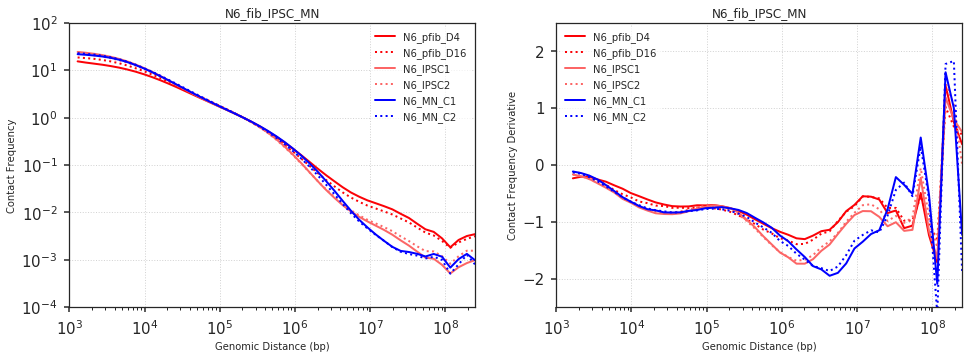

In [19]:
plt.clf()

gs = plt.GridSpec(nrows=12, ncols=2)
plt.figure(figsize=(16, 80))
plt.subplots_adjust(wspace=0.2, hspace=0.3)
def ScalePlotz():
    plt.xlim(1e3, 2.5e8)
    plt.ylim(1e-4, 1e2)
    #plt.grid(axis='x', which='minor', color='lightgray', linestyle=':', linewidth=0.5)
    plt.grid(axis='both', which='major', color='lightgray', linestyle=':', linewidth=1)
    plt.rc('font', weight='normal')
    plt.rc('xtick.major', size=5, pad=7, width=1.5)
    plt.rc('ytick.major', size=5, pad=7, width=1.5)
    #plt.rc('xtick.minor', size=3, pad=7, width=1)
    #plt.rc('ytick.minor', size=0)
    plt.rc('xtick', labelsize=15)
    plt.rc('ytick', labelsize=15)
    plt.legend(loc=0, shadow=False, fontsize='medium', frameon=True, facecolor='#FFFFFF', edgecolor='#FFFFFF', framealpha=0.7)
    plt.ylabel("Contact Frequency")
    plt.xlabel("Genomic Distance (bp)")
    
def DerivPlotz():
    plt.xlim(1e3, 2.5e8)
    plt.ylim(-2.5, 2.5)
    #plt.grid(axis='x', which='minor', color='lightgray', linestyle=':', linewidth=0.5)
    plt.grid(axis='both', which='major', color='lightgray', linestyle=':', linewidth=1)
    plt.rc('font', weight='normal')
    plt.rc('xtick.major', size=5, pad=7, width=1.5)
    plt.rc('ytick.major', size=5, pad=7, width=1.5)
    plt.rc('xtick.minor', size=3, pad=7, width=1)
    #plt.rc('ytick.minor', size=0)
    plt.rc('xtick', labelsize=15)
    plt.rc('ytick', labelsize=15)
    plt.legend(loc=0, shadow=False, fontsize='medium', frameon=True, facecolor='#FFFFFF', edgecolor='#FFFFFF', framealpha=0.7)
    ax = plt.gca()
    ax.set_xscale('log')
    plt.ylabel("Contact Frequency Derivative")
    plt.xlabel("Genomic Distance (bp)")

def DerivPlotzZoom():
    plt.xlim(5e3, 2e6)
    plt.ylim(-2.5, 2.5)
    plt.grid(axis='x', which='minor', color='lightgray', linestyle=':', linewidth=0.5)
    plt.grid(axis='both', which='major', color='lightgray', linestyle='-', linewidth=1)
    plt.rc('font', weight='normal')
    plt.rc('xtick.major', size=5, pad=7, width=1.5)
    plt.rc('ytick.major', size=5, pad=7, width=1.5)
    #plt.rc('xtick.minor', size=3, pad=7, width=1)
    #plt.rc('ytick.minor', size=0)
    plt.rc('xtick', labelsize=12)
    plt.rc('ytick', labelsize=12)
    plt.legend(loc=0, shadow=False, fontsize='small', frameon=True, facecolor='#FFFFFF', edgecolor='#FFFFFF', framealpha=0.7)
    ax = plt.gca()
    ax.set_xscale('log')
    plt.ylabel("Contact Frequency Derivative")
    plt.xlabel("Genomic Distance (bp)")

plt.subplot(gs[0])
for cond in conditions[0:6]:
    plt.loglog(scale_all[cond]["Distbins"][1:], scale_all[cond]["Avarage"]/scale_all[cond]["Avarage"][20], lw=2, ls=groupLine[cond], label = cond, color=timeColors[cond])
    plt.title('N6_fib_IPSC_MN')
    ScalePlotz()

plt.subplot(gs[1])
for cond in conditions[0:6]:
    delta_x = np.diff(np.log(scipy.ndimage.filters.gaussian_filter1d(scale_all[cond]["Distbins"], sigma=0.1)))
    delta_y = np.diff(np.log(scipy.ndimage.filters.gaussian_filter1d((scale_all[cond]["Avarage"]),sigma=0.1)))
    plt.plot(scale_all[cond]["Distbins"][2:], delta_y/delta_x[:1], lw=2, ls=groupLine[cond], label = cond, color=timeColors[cond])
    plt.title('N6_fib_IPSC_MN')
    DerivPlotz()

from matplotlib.backends.backend_pdf import PdfPages
pp = PdfPages(f'{figureDir}N6__fib_IPSC_MN_only.pdf')
plt.savefig(pp, format='pdf')
pp.close()